<a href="https://colab.research.google.com/github/rachel-kim2255/Machine-Learning-Notebooks/blob/main/3_%5BKNN_Model%5D_Wine_Class_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reference**  
Main Textbook: This project follows the examples and methodology from "데싸노트의 실전에서 통하는 머신러닝" (Machine Learning for Real-world Practices) by Sihyeon Kwon, published by Golden Rabbit (2022).  
Official Repository: https://github.com/musthave-ML10

---

# [KNN Model] Wine Class Prediction

Goal: To analyze the wine dataset and predict wine grades using the KNN (K-Nearest Neighbors) model

### KNN Model(K-Nearest Neighbors)

KNN is a distance-based algorithm that predicts outcomes by examining the K closest neighbors in the dataset. When a new data point is given, the model finds the K nearest data points in the training set.

- For classification, it predicts the class by majority voting among the neighbors.

- For regression, it predicts the value by taking the average of the neighbors.

**Characteristics**

- KNN is a lazy learning algorithm because it does not build an explicit model during training.

- It is distance-based, so the choice of distance metric (commonly Euclidean distance) is important.

- Feature scaling (normalization or standardization) is required since distances are sensitive to scale.

**Pros**
- Simple and intuitive to understand.
- No assumptions about data distribution.

**Cons**
- Prediction becomes slow as the dataset grows.
- Performance is highly sensitive to the choice of K.
- Easily affected by outliers.

## **1. Data Loading and Inspection**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_url = 'https://media.githubusercontent.com/media/musthave-ML10/data_source/main/wine.csv'
df = pd.read_csv(file_url)

In [3]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,NaN,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       176 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    int64  
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          173 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    int64  
 13  class

First, looking at the dataset, the target variable for prediction is "class."

- Since all variables are numeric, the Dtypes are either int or float.

- The total dataset length is 178, which is quite small.

- Nulls: There are missing values in two variables.(176 for alcohol and 173 for nonflavanoid_phenols)

In [5]:
round(df.describe(),2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,176.00,178.00,178.00,178.00,178.00,178.00,178.00,173.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,12.99,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.80,1.12,0.27,3.34,14.28,0.63,1.00,0.13,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.26,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.67,3.08,2.56,21.50,107.00,2.80,2.88,0.45,1.95,6.20,1.12,3.17,985.00,2.00
max,14.75,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


From the statistical summary of the dataset:

1. The variables are on different scales.  
- **nonflavanoid_phenols**: minimum value is 0.13 and maximum value is 0.66  
- **proline**: minimum value is 314.91 and maximum value is 1680  
- Since the scales of the variables differ significantly, scaling is required.

2. Outliers  
- For **color_intensity**, comparing the 75th percentile and the maximum value shows an increase of more than twofold.  
- Such outliers may affect modeling performance depending on the context.

## **2. Target Variable**



Since the appropriate algorithm depends on the nature of the target variable (continuous, binary, or categorical), I will first verify its type.

- Continuous variable: We can inspect it directly using `head()`, so no additional processing is required.
- Binary variable: If the dataset clearly consists of 0 and 1 values, no further preprocessing is necessary.

When working with a new dataset and the composition of the target variable is unknown, it can be verified using these approaches.

In [6]:
print("unique value of class: ",df['class'].unique())
print("The Number of unique value: ",df['class'].nunique())
print("\n----value counts----")
print(df['class'].value_counts())

unique value of class:  [0 1 2]
The Number of unique value:  3

----value counts----
class
1    71
0    59
2    48
Name: count, dtype: int64


By applying the `unique()` function to the target variable, we can identify the distinct values it contains.

- The current `class` variable has three unique values: 0, 1, and 2.  
- This indicates that the wine quality is categorized into three classes.  
- Class 1 has the highest frequency with 71 instances, while Class 2 has the lowest with 48 instances.

<Axes: xlabel='class', ylabel='count'>

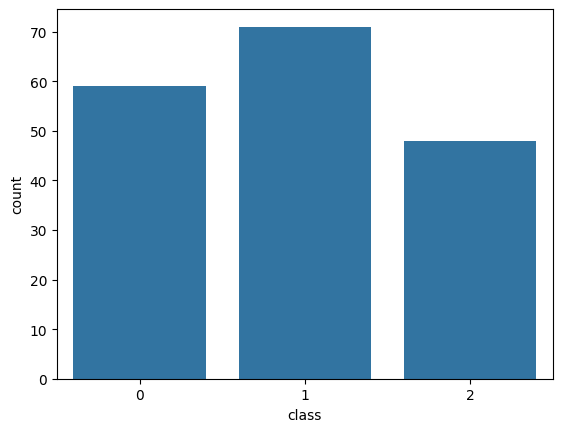

In [7]:
sns.barplot(x=df['class'].value_counts().index, y=df['class'].value_counts())

In [8]:
# Same Results
# # 1.
# sns.countplot(x=df['class'])
# # 2.
# sns.countplot(data=df, x='class')

## **3. Handling Missing Value**

In [9]:
df.isna()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,False,False,False,False,False,False,False,False,False,False,False,False,False,False
174,False,False,False,False,False,False,False,False,False,False,False,False,False,False
175,False,False,False,False,False,False,False,False,False,False,False,False,False,False
176,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.sum()

,0
alcohol,2286.080000
malic_acid,415.870000
ash,421.240000
alcalinity_of_ash,3470.100000
magnesium,17754.000000
total_phenols,408.530000
flavanoids,361.210000
nonflavanoid_phenols,62.690000
proanthocyanins,283.180000
color_intensity,900.339999


In [11]:
df.isna().sum() # checking the number of missing value

,0
alcohol,2
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,5
proanthocyanins,0
color_intensity,0


In [12]:
round(df.isna().mean(),4) # checking the percentage of missing values

,0
alcohol,0.0112
malic_acid,0.0000
ash,0.0000
alcalinity_of_ash,0.0000
magnesium,0.0000
total_phenols,0.0000
flavanoids,0.0000
nonflavanoid_phenols,0.0281
proanthocyanins,0.0000
color_intensity,0.0000


- **alcohol**: approximately 1.12% missing values  
- **nonflavanoid_phenols**: approximately 2.81% missing values

### Handling Missing Values(1): `dropna()`

This method removes only the rows that contain missing values.

- Depending on the situation, this approach may result in excessive data loss. Therefore, `dropna()` should only be considered when the proportion of missing values is very low and the dataset is sufficiently large.

In [13]:
df.dropna() # eliminate missing values rows

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,2
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,2
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,2


The dataset was reduced to 171 rows.  
The reason 7 rows were removed is that the missing values in **alcohol** and **nonflavanoid_phenols** occurred in different rows.

In [14]:
df.dropna().isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [15]:
# df = df.dropna()
# df.dropna(inplace=True)

In [16]:
df.dropna(subset=['alcohol']) # to remove only alcohol's null

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,2
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,2
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,2


### Handling Missing Values (2): `drop()`

This method removes the entire variable (column) that contains missing values.

- If a variable has more than 50% missing values, `drop()` can be considered.  
- If the missing rate exceeds 70–80%, it is generally advisable to remove the variable.  
- However, even when more than 90% of the values are missing, if the variable plays a critical role in the project, it is often better to explore alternative ways to utilize it rather than removing it outright.

In [17]:
df.drop(['alcohol', 'nonflavanoid_phenols'], axis=1)

,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,1.71,2.43,15.6,127,2.80,3.06,2.29,5.64,1.04,3.92,1065,0
1,1.78,2.14,11.2,100,2.65,2.76,1.28,4.38,1.05,3.40,1050,0
2,2.36,2.67,18.6,101,2.80,3.24,2.81,5.68,1.03,3.17,1185,0
3,1.95,2.50,16.8,113,3.85,3.49,2.18,7.80,0.86,3.45,1480,0
4,2.59,2.87,21.0,118,2.80,2.69,1.82,4.32,1.04,2.93,735,0
...,...,...,...,...,...,...,...,...,...,...,...,...
173,5.65,2.45,20.5,95,1.68,0.61,1.06,7.70,0.64,1.74,740,2
174,3.91,2.48,23.0,102,1.80,0.75,1.41,7.30,0.70,1.56,750,2
175,4.28,2.26,20.0,120,1.59,0.69,1.35,10.20,0.59,1.56,835,2
176,2.59,2.37,20.0,120,1.65,0.68,1.46,9.30,0.60,1.62,840,2


The number of variables decreased from 14 to 12, as **alcohol** and **nonflavanoid_phenols** were removed.



### Handling Missing Values (3): `fillna()`

This method imputes missing values by filling them with a specified value.  
In general, the mean or median is commonly used for imputation.

In [18]:
df.fillna(df.mean()) # mean

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.230000,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,12.989091,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.160000,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.370000,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.240000,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.710000,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2
174,13.400000,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,2
175,13.270000,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,2
176,13.170000,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,2


In [19]:
df.fillna(df.median(), inplace=True) # updated with median

df.isna().mean() # checking missing value

,0
alcohol,0.0
malic_acid,0.0
ash,0.0
alcalinity_of_ash,0.0
magnesium,0.0
total_phenols,0.0
flavanoids,0.0
nonflavanoid_phenols,0.0
proanthocyanins,0.0
color_intensity,0.0


## **4. Scaling Test**

When I previously examined the statistical summary, observed substantial differences in scale across variables. Since KNN is a distance-based algorithm, such scale discrepancies can lead to distorted results.

e.g.,
- alcohol (Min: 11.03 / Max: 14.75)  
- magnesium (Min: 70 / Max: 162)  
- A difference of 1 has a completely different impact across these two variables.

Scaling addresses this issue by transforming each column so that they share a comparable range.

### Scaling

1. Standard Scaling: Centers the data to a mean of 0 and scales it to a standard deviation of 1.  
2. Robust Scaling: Used when outliers are present and you want to reduce their influence using robust statistics.  
3. Min-Max Scaling: Preserves the original distribution shape while rescaling values to a fixed range.  
4. Normalizer Scaling: Applied when row-wise normalization is required, though it is rarely used in practice.

### Important Considerations

- The target variable must be excluded from scaling.  
- Before scaling, split the data into train and test sets. Then use `fit()` on the training set to learn the scaling parameters, and apply those learned parameters to transform both the train and test sets.

In [20]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### (1) Standard Scaling

This method standardizes the data to follow a normal distribution. Each variable is transformed by subtracting its mean and dividing by its standard deviation, resulting in all columns following a standard normal distribution.

- After transformation, each column has a mean of 0 and a standard deviation of 1, allowing computations to occur on a more balanced scale.  
- Sensitive to outliers, and the original distribution shape of the data may be lost.

In [21]:
# Standard Scaling

st_scaler = StandardScaler() # 스케일러 지정

st_scaler.fit(df) # Learnig

st_scaled = st_scaler.transform(df) # 학습에서 얻은 정보로 데이터를 변환 - scaling하는 함수

st_scaled


array([[ 1.55484903, -0.5622498 ,  0.23205254, ...,  1.84791957,
         1.01300893, -1.21394365],
       [ 0.07550273, -0.49941338, -0.82799632, ...,  1.1134493 ,
         0.96524152, -1.21394365],
       [ 0.21340789,  0.02123125,  1.10933436, ...,  0.78858745,
         1.39514818, -1.21394365],
       ...,
       [ 0.35131305,  1.74474449, -0.38935541, ..., -1.48544548,
         0.28057537,  1.37386437],
       [ 0.22594472,  0.22769377,  0.01273209, ..., -1.40069891,
         0.29649784,  1.37386437],
       [ 1.4294807 ,  1.58316512,  1.36520822, ..., -1.42894777,
        -0.59516041,  1.37386437]])

In [22]:
pd.DataFrame(st_scaled)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.554849,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.658865,1.224884,0.251717,0.362177,1.847920,1.013009,-1.213944
1,0.075503,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820072,-0.544721,-0.293321,0.406051,1.113449,0.965242,-1.213944
2,0.213408,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.497658,2.135968,0.269020,0.318304,0.788587,1.395148,-1.213944
3,1.730365,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981279,1.032155,1.186068,-0.427544,1.184071,2.334574,-1.213944
4,0.313703,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.227773,0.401404,-0.319276,0.362177,0.449601,-0.037874,-1.213944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.902934,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.275618,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,1.373864
174,0.514292,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.550187,-0.316950,0.969783,-1.129518,-1.485445,0.009893,1.373864
175,0.351313,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.550187,-0.422075,2.224236,-1.612125,-1.485445,0.280575,1.373864
176,0.225945,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.356221,-0.229346,1.834923,-1.568252,-1.400699,0.296498,1.373864


In [23]:
st_scaled=pd.DataFrame(st_scaled, columns=df.columns) # change the column's name
st_scaled

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,1.554849,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.658865,1.224884,0.251717,0.362177,1.847920,1.013009,-1.213944
1,0.075503,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820072,-0.544721,-0.293321,0.406051,1.113449,0.965242,-1.213944
2,0.213408,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.497658,2.135968,0.269020,0.318304,0.788587,1.395148,-1.213944
3,1.730365,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981279,1.032155,1.186068,-0.427544,1.184071,2.334574,-1.213944
4,0.313703,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.227773,0.401404,-0.319276,0.362177,0.449601,-0.037874,-1.213944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.902934,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.275618,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,1.373864
174,0.514292,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.550187,-0.316950,0.969783,-1.129518,-1.485445,0.009893,1.373864
175,0.351313,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.550187,-0.422075,2.224236,-1.612125,-1.485445,0.280575,1.373864
176,0.225945,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.356221,-0.229346,1.834923,-1.568252,-1.400699,0.296498,1.373864


In [24]:
round(st_scaled.describe(),2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.46,-1.43,-3.68,-2.67,-2.09,-2.11,-1.70,-1.87,-2.07,-1.63,-2.09,-1.90,-1.49,-1.21
25%,-0.79,-0.66,-0.57,-0.69,-0.82,-0.89,-0.83,-0.74,-0.60,-0.80,-0.77,-0.95,-0.78,-1.21
50%,0.08,-0.42,-0.02,0.00,-0.12,0.10,0.11,-0.18,-0.06,-0.16,0.03,0.24,-0.23,0.08
75%,0.84,0.67,0.70,0.60,0.51,0.81,0.85,0.61,0.63,0.49,0.71,0.79,0.76,1.37
max,2.21,3.11,3.16,3.15,4.37,2.54,3.06,2.40,3.49,3.44,3.30,1.96,2.97,1.37


### (2) Robust Scaling

When outliers are present, this method is robust to their influence.  
The range of the transformed data tends to be wider compared to Standard Scaling or Min-Max Scaling.

In [25]:
rb_scaler=RobustScaler()

rb_scaled = rb_scaler.fit_transform(df)
rb_scaled = pd.DataFrame(rb_scaled, columns=df.columns)

round(rb_scaled.describe(), 2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,-0.05,0.32,0.02,-0.00,0.09,-0.06,-0.06,0.13,0.05,0.12,-0.02,-0.14,0.15,-0.03
std,0.62,0.75,0.79,0.78,0.75,0.59,0.60,0.74,0.82,0.78,0.68,0.58,0.65,0.39
min,-1.55,-0.76,-2.88,-2.07,-1.47,-1.30,-1.07,-1.25,-1.64,-1.14,-1.44,-1.23,-0.82,-0.50
25%,-0.53,-0.18,-0.43,-0.53,-0.53,-0.58,-0.56,-0.42,-0.44,-0.49,-0.54,-0.68,-0.36,-0.50
50%,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00
75%,0.47,0.82,0.57,0.47,0.47,0.42,0.44,0.58,0.56,0.51,0.46,0.32,0.64,0.50
max,1.31,2.66,2.50,2.44,3.37,1.44,1.76,1.91,2.89,2.79,2.21,0.99,2.08,0.50


### (3) Min/Max Scaling

All variables are scaled so that their minimum and maximum values become 0 and 1, respectively.  

- This method is influenced by outliers.  
- It preserves the original distribution of the data as much as possible while adjusting the scale.  
- After transformation, all values fall within the range of 0 to 1.

In [26]:
mm_scaler = MinMaxScaler()
mm_scaled = mm_scaler.fit_transform(df)
mm_scaled = pd.DataFrame(mm_scaled, columns=df.columns)
round(mm_scaled.describe(), 2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,0.53,0.32,0.54,0.46,0.32,0.45,0.36,0.44,0.37,0.32,0.39,0.49,0.33,0.47
std,0.22,0.22,0.15,0.17,0.16,0.22,0.21,0.23,0.18,0.20,0.19,0.26,0.22,0.39
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.36,0.17,0.45,0.34,0.20,0.26,0.18,0.26,0.26,0.17,0.25,0.24,0.16,0.00
50%,0.54,0.22,0.53,0.46,0.30,0.47,0.38,0.40,0.36,0.29,0.39,0.55,0.28,0.50
75%,0.71,0.46,0.64,0.56,0.40,0.63,0.53,0.58,0.49,0.42,0.52,0.70,0.50,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## **5. Applying Scaling**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis=1), df['class'], test_size=0.2, random_state=100)

mm_scaler = MinMaxScaler()
X_train_scaled = mm_scaler.fit_transform(X_train)
X_test_scaled = mm_scaler.transform(X_test)


In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
pred

array([1, 2, 0, 1, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0,
       2, 1, 0, 0, 1, 1, 1, 2, 2, 1, 0, 1, 2, 2])

I instantiated the algorithm using the `KNeighborsClassifier()` function, trained it with `fit()`, and made predictions using `predict()`.

The variable `pred` contains the predicted class for each instance, corresponding to 0, 1, or 2.

I will evaluate how well the predictions match the true labels `y_test` using `accuracy_score()`.

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.8888888888888888

Accuracy Score: approximately 88.9%

## **6. Hyperparameter Tuning**

In the KNN algorithm, the `n_neighbors` parameter specifies the number of neighbors to consider for making predictions.  

The default value is 5, so in the following code, we will change it to 7 and then evaluate the resulting accuracy.

In [30]:
knn = KNeighborsClassifier(n_neighbors = 7) # n_neighbors = 7
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
accuracy_score(y_test, pred)

0.9166666666666666

In [31]:
knn = KNeighborsClassifier(n_neighbors = 3) # n_neighbors = 3
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
accuracy_score(y_test, pred)

0.8888888888888888

The accuracy changes depending on the value of `n_neighbors`.  
To find the number that yields the highest accuracy, I will modify the code to iterate over an appropriate range of values.

In [33]:
for i in range(1, 21):
  knn = KNeighborsClassifier(n_neighbors= i)
  knn.fit(X_train_scaled, y_train)
  pred = knn.predict(X_test_scaled)
  accuracy_score(y_test, pred)
  print("[",i,"]: ",accuracy_score(y_test, pred))

[ 1 ]:  0.9166666666666666
[ 2 ]:  0.8888888888888888
[ 3 ]:  0.8888888888888888
[ 4 ]:  0.9166666666666666
[ 5 ]:  0.8888888888888888
[ 6 ]:  0.9166666666666666
[ 7 ]:  0.9166666666666666
[ 8 ]:  0.8888888888888888
[ 9 ]:  0.8888888888888888
[ 10 ]:  0.8888888888888888
[ 11 ]:  0.9166666666666666
[ 12 ]:  0.9166666666666666
[ 13 ]:  0.9722222222222222
[ 14 ]:  0.9444444444444444
[ 15 ]:  0.9444444444444444
[ 16 ]:  0.9444444444444444
[ 17 ]:  0.9166666666666666
[ 18 ]:  0.9722222222222222
[ 19 ]:  0.9444444444444444
[ 20 ]:  0.9722222222222222


In [38]:
results = []
scores = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)

    # add results to lists
    results.append((acc, i)) # to check the highest n
    scores.append(acc) # to make a list


# sort the result by accuracy
results.sort(reverse=True)

# print
for acc, i in results:
    print(f"[{i}]: {acc}")


[20]: 0.9722222222222222
[18]: 0.9722222222222222
[13]: 0.9722222222222222
[19]: 0.9444444444444444
[16]: 0.9444444444444444
[15]: 0.9444444444444444
[14]: 0.9444444444444444
[17]: 0.9166666666666666
[12]: 0.9166666666666666
[11]: 0.9166666666666666
[7]: 0.9166666666666666
[6]: 0.9166666666666666
[4]: 0.9166666666666666
[1]: 0.9166666666666666
[10]: 0.8888888888888888
[9]: 0.8888888888888888
[8]: 0.8888888888888888
[5]: 0.8888888888888888
[3]: 0.8888888888888888
[2]: 0.8888888888888888
[0.9166666666666666, 0.8888888888888888, 0.8888888888888888, 0.9166666666666666, 0.8888888888888888, 0.9166666666666666, 0.9166666666666666, 0.8888888888888888, 0.8888888888888888, 0.8888888888888888, 0.9166666666666666, 0.9166666666666666, 0.9722222222222222, 0.9444444444444444, 0.9444444444444444, 0.9444444444444444, 0.9166666666666666, 0.9722222222222222, 0.9444444444444444, 0.9722222222222222]


In [37]:
scores

[0.9166666666666666,
 0.8888888888888888,
 0.8888888888888888,
 0.9166666666666666,
 0.8888888888888888,
 0.9166666666666666,
 0.9166666666666666,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9166666666666666,
 0.9166666666666666,
 0.9722222222222222,
 0.9444444444444444,
 0.9444444444444444,
 0.9444444444444444,
 0.9166666666666666,
 0.9722222222222222,
 0.9444444444444444,
 0.9722222222222222]

<Axes: >

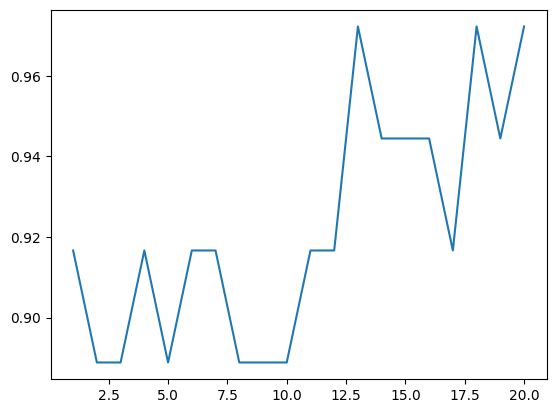

In [40]:
sns.lineplot(x=range(1,21), y=scores)

The values 13, 18, and 20 all produce the same accuracy, representing the best performance within the tested range.  
When multiple values yield the same result, it is reasonable to choose the one that requires less computation, so the optimal parameter is 13.

In [41]:
knn = KNeighborsClassifier(n_neighbors = 13) # n_neighbors = 13
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
accuracy_score(y_test, pred)

0.9722222222222222